# Week 37: the particle-hole formalism, the normal-ordered Hamiltonian, bit patterns and full configuration interaction -- selected codes

**FYS4480/FYS9480, Quantum mechanics for many-particle systems**
Morten Hjorth-Jensen, Department of Physics and Center for Computing in Science Education, University of Oslo

This notebook accompanies the week-37 slides (`week37.tex`), sections 3.4, 3.5, 3.13--3.16 of chapter 3 and chapter 5 of the lecture notes. As in weeks 35 and 36, every fermion operator is an explicit matrix on the $2^n$ states of a small Fock space, so that every identity of the lectures can be checked as a matrix identity to machine precision. New this week: normal ordering *with respect to the reference determinant* $|c\rangle$, the normal-ordered Hamiltonian $\hat H=E_{\rm ref}+\hat F_N+\hat V_N$ derived and verified term by term, the particle-hole examples of the slides with numbers, and a complete (if small) full configuration-interaction code built on the bit representation of section 3.16 -- the strategy of `BookPrograms/chapter05/fci.py`.

The sections follow the lectures:

1. Fermion operators as matrices; a random Hamiltonian (reminder)
2. Wick's generalised theorem as an operator identity, and the Condon-Slater rules (sections 3.13--3.15)
3. Section 3.4: the reference state $|c\rangle$, quasiparticle operators, the two Fermi-vacuum contractions
4. Section 3.5: the normal-ordered Hamiltonian $\hat H = E_{\rm ref}+\hat F_N+\hat V_N$, derived by Wick's theorem and verified as a matrix identity
5. Particle-hole examples: $E_{\rm ref}$, $\langle\Phi_i^a|\hat H|c\rangle=f_{ai}$, $\langle\Phi_{ij}^{ab}|\hat H|c\rangle=\langle ab|v|ij\rangle$, the energy of a $1p1h$ state, and the particle/hole blocks of $\hat F_N$ and $\hat V_N$
6. The pairing model in particle-hole language, with numbers
7. Section 3.16: Slater determinants as bit patterns, and $\hat H|\Phi\rangle$ by bit operations
8. Chapter 5: full configuration interaction for the pairing model -- the determinant basis, the block structure of the Hamiltonian matrix, the $70$-dimensional and the $6$-dimensional calculations, truncations, size consistency
9. The exponential wall

In [1]:
import numpy as np
from itertools import combinations, permutations
from math import comb, factorial
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True, linewidth=120)
rng = np.random.default_rng(2037)

## 1. Fermion operators as matrices, and a random Hamiltonian (reminder)

A Slater determinant over $n$ single-particle states is an $n$-bit integer, bit $p$ set when orbital $p$ is occupied. $a_p$ clears bit $p$ and multiplies by $(-1)^l$, $l$ the number of occupied orbitals below $p$; $a_p^\dagger$ is its transpose. The Hamiltonian is the one of the lectures,
$$\hat H=\sum_{pq}\langle p|\hat h_0|q\rangle a_p^\dagger a_q+\tfrac14\sum_{pqrs}\langle pq|\hat v|rs\rangle_{\rm AS}\,a_p^\dagger a_q^\dagger a_s a_r ,$$
with random Hermitian one-body elements and random antisymmetrised two-body elements.

In [2]:
class FockSpace:
    '''Fermion creation/annihilation operators as matrices on 2^n Fock states.'''

    def __init__(self, n_orbitals):
        self.n = n_orbitals
        self.dim = 1 << n_orbitals
        self._a = [self._annihilate(p) for p in range(n_orbitals)]
        self._adag = [M.T.copy() for M in self._a]

    def _annihilate(self, p):
        M = np.zeros((self.dim, self.dim))
        for state in range(self.dim):
            if state & (1 << p):
                sign = (-1) ** bin(state & ((1 << p) - 1)).count("1")
                M[state ^ (1 << p), state] = sign
        return M

    def annihilate(self, p):
        return self._a[p]

    def create(self, p):
        return self._adag[p]

    def vacuum(self):
        v = np.zeros(self.dim)
        v[0] = 1.0
        return v

    def op(self, index, dagger):
        return self._adag[index] if dagger else self._a[index]

    def string(self, ops):
        '''Matrix of a product of operators; ops = [(index, dagger), ...], leftmost first.'''
        M = np.eye(self.dim)
        for index, dagger in ops:
            M = M @ self.op(index, dagger)
        return M

    def determinant(self, occupied):
        '''|p1 p2 ... pN> = a_p1^+ a_p2^+ ... a_pN^+ |0>, in the order given.'''
        v = self.vacuum()
        for p in reversed(occupied):
            v = self._adag[p] @ v
        return v


def anticommutator(A, B):
    return A @ B + B @ A

c = lambda p: (p, True)      # a_p^dagger
d = lambda p: (p, False)     # a_p

def random_onebody(n):
    h = rng.normal(size=(n, n))
    return (h + h.T) / 2

def random_twobody(n):
    '''<pq|v|rs> real with <pq|v|rs> = <qp|v|sr> = <rs|v|pq>.'''
    v = rng.normal(size=(n, n, n, n))
    v = v + v.transpose(1, 0, 3, 2)
    v = v + v.transpose(2, 3, 0, 1)
    return v

def antisymmetrise(v):
    return v - v.transpose(0, 1, 3, 2)

def onebody_operator(space, h):
    n = space.n
    return sum(h[p, q] * space.create(p) @ space.annihilate(q) for p in range(n) for q in range(n))

def twobody_operator(space, vAS):
    '''1/4 sum <pq|v|rs>_AS a_p^+ a_q^+ a_s a_r.'''
    n = space.n
    H = np.zeros((space.dim, space.dim))
    for p in range(n):
        for q in range(n):
            cc = space.create(p) @ space.create(q)
            for r in range(n):
                for s in range(n):
                    if vAS[p, q, r, s] != 0.0:
                        H += 0.25 * vAS[p, q, r, s] * cc @ space.annihilate(s) @ space.annihilate(r)
    return H

n = 6                         # six orbitals, 64 Fock states
space = FockSpace(n)
a = [space.annihilate(p) for p in range(n)]
adag = [space.create(p) for p in range(n)]
I = np.eye(space.dim)
vac = space.vacuum()

h0 = random_onebody(n)
vAS = antisymmetrise(random_twobody(n))
H0 = onebody_operator(space, h0)
HI = twobody_operator(space, vAS)
H = H0 + HI
Nhat = sum(adag[p] @ a[p] for p in range(n))

ok = all(np.allclose(anticommutator(a[p], adag[q]), (p == q) * I) for p in range(n) for q in range(n))
print("{a_p, a_q^+} = delta_pq                :", ok)
print("H Hermitian                            :", np.allclose(H, H.T))
print("[N, H] = 0                             :", np.allclose(Nhat @ H, H @ Nhat))

{a_p, a_q^+} = delta_pq                : True
H Hermitian                            : True
[N, H] = 0                             : True


## 2. Wick's generalised theorem, and the Condon-Slater rules (sections 3.13--3.15)

For a product of normal-ordered groups only the **inter-group** contractions appear,
$$N[A_1A_2\cdots]\,N[B_1B_2\cdots]\,N[C_1C_2\cdots]=N[A_1A_2\cdots B_1B_2\cdots C_1C_2\cdots]+\sum_{\text{inter-group}}N[\cdots].$$
`wick_generalised` sums over all partial matchings that join different groups, with the sign of the permutation that brings the contracted pairs to the front, and is compared with the plain product of the groups as matrices. Then the two applications of the lecture: the four-term formula for $\langle ij|\hat O^{(1)}|k\ell\rangle$ and $\langle k\ell|\hat H_I|ij\rangle=\langle k\ell|v|ij\rangle_{\rm AS}$, and the sparsity rule -- a two-body operator does not connect determinants differing by three or more orbitals.

In [3]:
def normal_order(ops):
    '''(sign, reordered) with respect to the true vacuum: creation operators first.'''
    creators = [o for o in ops if o[1]]
    annihilators = [o for o in ops if not o[1]]
    swaps = sum(1 for i, o in enumerate(ops) if not o[1] for p in ops[i + 1:] if p[1])
    return (-1) ** swaps, tuple(creators + annihilators)

def normal_product(space, ops):
    sign, reordered = normal_order(ops)
    return sign * space.string(reordered)

def contraction_value(x, y):
    '''<0| x y |0>: only a_p a_q^+ with p == q survives.'''
    return 1.0 if (not x[1]) and y[1] and x[0] == y[0] else 0.0

def partial_matchings(indices):
    if not indices:
        yield []
        return
    first, rest = indices[0], indices[1:]
    for tail in partial_matchings(rest):
        yield tail
    for k in range(len(rest)):
        for tail in partial_matchings(rest[:k] + rest[k + 1:]):
            yield [(first, rest[k])] + tail

def permutation_parity(perm):
    perm = list(perm); parity = 0
    for i in range(len(perm)):
        while perm[i] != i:
            j = perm[i]; perm[i], perm[j] = perm[j], perm[i]; parity ^= 1
    return -1 if parity else 1

def wick_generalised(space, groups, contraction=contraction_value, normal=normal_product):
    '''RHS of the generalised theorem as a matrix; each group already normal-ordered.'''
    ops = tuple(o for g in groups for o in g)
    label = [gi for gi, g in enumerate(groups) for _ in g]
    M = len(ops)
    total = np.zeros((space.dim, space.dim))
    for pairs in partial_matchings(list(range(M))):
        if any(label[A] == label[B] for A, B in pairs):
            continue
        value = 1.0
        for A, B in pairs:
            value *= contraction(ops[A], ops[B])
            if value == 0.0:
                break
        if value == 0.0:
            continue
        contracted = [i for pair in pairs for i in pair]
        rest = [i for i in range(M) if i not in contracted]
        total += permutation_parity(contracted + rest) * value * normal(space, [ops[i] for i in rest])
    return total

def random_group(size):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(size)]
    return list(normal_order(ops)[1])

ok = True
for ngroups in [2, 3]:
    for _ in range(15):
        groups = [random_group(int(rng.integers(1, 4))) for _ in range(ngroups)]
        lhs = np.eye(space.dim)
        for g in groups:
            lhs = lhs @ space.string(g)
        ok &= np.allclose(lhs, wick_generalised(space, groups))
print("generalised theorem as operator identity, 2 and 3 groups :", ok)

# Condon-Slater rules between two-particle determinants
def onebody_formula(h, i, j, k, l):
    return (j == l) * h[i, k] - (j == k) * h[i, l] - (i == l) * h[j, k] + (i == k) * h[j, l]

ok1 = all(np.isclose(space.determinant((i, j)) @ H0 @ space.determinant((k, l)), onebody_formula(h0, i, j, k, l))
          for (i, j) in permutations(range(n), 2) for (k, l) in permutations(range(n), 2))
pairs = list(combinations(range(n), 2))
ok2 = all(np.isclose(space.determinant(kl) @ HI @ space.determinant(ij), vAS[kl[0], kl[1], ij[0], ij[1]])
          for kl in pairs for ij in pairs)
print("<ij|O1|kl> = four-term formula, all index choices        :", ok1)
print("<kl|H_I|ij> = <kl|v|ij>_AS, all pairs                    :", ok2)

# sparsity: three-particle determinants differing by three orbitals are not connected by H
bra = space.determinant((0, 1, 2)); ket = space.determinant((3, 4, 5))
print("<012|H|345> (three orbitals replaced)                    :", bra @ H @ ket)

generalised theorem as operator identity, 2 and 3 groups : True
<ij|O1|kl> = four-term formula, all index choices        : True
<kl|H_I|ij> = <kl|v|ij>_AS, all pairs                    : True
<012|H|345> (three orbitals replaced)                    : 0.0


## 3. Section 3.4: the reference state, quasiparticle operators and the Fermi-vacuum contractions

We fill the lowest $n_c=3$ orbitals: $|c\rangle=a_0^\dagger a_1^\dagger a_2^\dagger|0\rangle$, Fermi level $F=2$. Hole labels $i,j,k,\ldots\in\{0,1,2\}$, particle labels $a,b,c,\ldots\in\{3,4,5\}$. The quasiparticle operators are
$$b_a^\dagger=a_a^\dagger,\quad b_a=a_a\ (a>F),\qquad b_i^\dagger=a_i,\quad b_i=a_i^\dagger\ (i\le F),$$
and we verify $b_\alpha|c\rangle=0$, the anticommutation relations, the two number operators $\hat N$ and $\hat N_{qp}$, and the two surviving contractions with respect to $|c\rangle$,
$$\langle c|a_aa_b^\dagger|c\rangle=\delta_{ab},\qquad \langle c|a_i^\dagger a_j|c\rangle=\delta_{ij},$$
all other pairs vanishing.

In [4]:
F = 2
holes = [p for p in range(n) if p <= F]
particles = [p for p in range(n) if p > F]
ref = space.determinant(holes)                    # |c> = a_0^+ a_1^+ a_2^+ |0>

def b(p):        # quasiparticle annihilation
    return a[p] if p > F else adag[p]
def bdag(p):     # quasiparticle creation
    return adag[p] if p > F else a[p]

print("b_alpha |c> = 0 for all alpha           :", all(np.allclose(b(p) @ ref, 0) for p in range(n)))
print("{b_a^+, b_b} = delta_ab                 :",
      all(np.allclose(anticommutator(bdag(p), b(q)), (p == q) * I) for p in range(n) for q in range(n)))
print("{b_a^+, b_b^+} = {b_a, b_b} = 0         :",
      all(np.allclose(anticommutator(bdag(p), bdag(q)), 0) and np.allclose(anticommutator(b(p), b(q)), 0)
          for p in range(n) for q in range(n)))

Nqp = sum(bdag(p) @ b(p) for p in range(n))
ph = bdag(4) @ bdag(1) @ ref                      # one-particle-one-hole state |4 1^{-1}>
print("N   |4 1^-1> = 3 |4 1^-1>               :", np.allclose(Nhat @ ph, 3 * ph))
print("Nqp |4 1^-1> = 2 |4 1^-1>               :", np.allclose(Nqp @ ph, 2 * ph))
print("N = sum_a b_a^+ b_a + n_c - sum_i b_i^+ b_i :",
      np.allclose(Nhat, sum(bdag(p) @ b(p) for p in particles) + len(holes) * I - sum(bdag(p) @ b(p) for p in holes)))

# the contractions with respect to |c>: <c| x y |c> for all pairs of a, a^+
def fermi_contraction(x, y):
    '''<c| x y |c> for x, y in {a_p, a_p^+}: the two surviving types.'''
    (p, xd), (q, yd) = x, y
    if (not xd) and yd and p == q and p > F:  return 1.0     # a_a a_b^+ , particles
    if xd and (not yd) and p == q and p <= F: return 1.0     # a_i^+ a_j , holes
    return 0.0

ok = all(np.isclose(ref @ space.string([x, y]) @ ref, fermi_contraction(x, y))
         for x in [c(p) for p in range(n)] + [d(p) for p in range(n)]
         for y in [c(p) for p in range(n)] + [d(p) for p in range(n)])
print("<c|xy|c>: only a_a a_b^+ (a=b>F) and a_i^+ a_j (i=j<=F) survive :", ok)

b_alpha |c> = 0 for all alpha           : True
{b_a^+, b_b} = delta_ab                 : True
{b_a^+, b_b^+} = {b_a, b_b} = 0         : True
N   |4 1^-1> = 3 |4 1^-1>               : True
Nqp |4 1^-1> = 2 |4 1^-1>               : True
N = sum_a b_a^+ b_a + n_c - sum_i b_i^+ b_i : True
<c|xy|c>: only a_a a_b^+ (a=b>F) and a_i^+ a_j (i=j<=F) survive : True


## 4. Section 3.5: the normal-ordered Hamiltonian

Normal ordering **with respect to $|c\rangle$** puts the quasiparticle creation operators $a_a^\dagger$ and $a_i$ to the left of the quasiparticle annihilation operators $a_a$ and $a_i^\dagger$; we write it $\{\cdots\}$. Wick's theorem holds word for word with the two contractions of section 3, and applied to the Hamiltonian it gives (slides, Thursday lecture 2)
$$\hat H = E_{\rm ref}+\hat F_N+\hat V_N,\qquad
E_{\rm ref}=\sum_i\langle i|\hat h_0|i\rangle+\tfrac12\sum_{ij}\langle ij|\hat v|ij\rangle_{\rm AS},$$
$$\hat F_N=\sum_{pq}f_{pq}\{a_p^\dagger a_q\},\quad f_{pq}=\langle p|\hat h_0|q\rangle+\sum_i\langle pi|\hat v|qi\rangle_{\rm AS},\qquad
\hat V_N=\tfrac14\sum_{pqrs}\langle pq|\hat v|rs\rangle_{\rm AS}\{a_p^\dagger a_q^\dagger a_s a_r\}.$$
The derivation uses, for the two-body string, the four single contractions with signs $-,+,+,-$ and the two double contractions with signs $-,+$:
$$a_p^\dagger a_q^\dagger a_s a_r=\{a_p^\dagger a_q^\dagger a_s a_r\}
-\delta_{ps}^{h}\{a_q^\dagger a_r\}+\delta_{pr}^{h}\{a_q^\dagger a_s\}+\delta_{qs}^{h}\{a_p^\dagger a_r\}-\delta_{qr}^{h}\{a_p^\dagger a_s\}
+\delta_{pr}^{h}\delta_{qs}^{h}-\delta_{ps}^{h}\delta_{qr}^{h},$$
with $\delta^{h}_{pq}=\delta_{pq}$ if $p$ is a hole state and $0$ otherwise. Every line below is checked as a matrix identity: first the four-operator expansion for all $6^4$ index choices, then the three pieces of $\hat H$.

In [5]:
def is_qp_creator(o):
    '''a_a^+ (a > F) and a_i (i <= F) create quasiparticles.'''
    p, dagger = o
    return dagger if p > F else (not dagger)

def normal_order_c(ops):
    '''(sign, reordered) with respect to |c>: quasiparticle creators first, relative orders kept.'''
    creators = [o for o in ops if is_qp_creator(o)]
    annihilators = [o for o in ops if not is_qp_creator(o)]
    swaps = sum(1 for i, o in enumerate(ops) if not is_qp_creator(o) for p in ops[i + 1:] if is_qp_creator(p))
    return (-1) ** swaps, tuple(creators + annihilators)

def normal_product_c(space, ops):
    sign, reordered = normal_order_c(ops)
    return sign * space.string(reordered)

# <c|{any non-empty string}|c> = 0, and x y - {x y} = <c|xy|c>
ok = True
for _ in range(200):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(int(rng.integers(1, 7)))]
    ok &= np.isclose(ref @ normal_product_c(space, ops) @ ref, 0)
print("<c|{any non-empty string}|c> = 0                       :", ok)
allops = [c(p) for p in range(n)] + [d(p) for p in range(n)]
ok = all(np.allclose(space.string([x, y]) - normal_product_c(space, [x, y]), fermi_contraction(x, y) * I)
         for x in allops for y in allops)
print("x y - {x y} = <c|x y|c> * 1, all pairs                 :", ok)

# Wick's theorem with respect to |c> as an operator identity, random strings up to six operators
ok = True
for _ in range(100):
    ops = [(int(rng.integers(0, n)), bool(rng.integers(0, 2))) for _ in range(int(rng.integers(2, 7)))]
    ok &= np.allclose(space.string(ops), wick_generalised(space, [[o] for o in ops], fermi_contraction, normal_product_c))
print("Wick's theorem relative to |c>, random strings          :", ok)

# the four-operator expansion used in the derivation, every index choice
hole = lambda p, q: float(p == q and p <= F)     # delta^h_pq
def N2(p, q):  return normal_product_c(space, [c(p), d(q)])
def N4(p, q, r, s): return normal_product_c(space, [c(p), c(q), d(s), d(r)])
ok = True
for p in range(n):
    for q in range(n):
        for r in range(n):
            for s in range(n):
                lhs = space.string([c(p), c(q), d(s), d(r)])
                rhs = (N4(p, q, r, s)
                       - hole(p, s) * N2(q, r) + hole(p, r) * N2(q, s) + hole(q, s) * N2(p, r) - hole(q, r) * N2(p, s)
                       + (hole(p, r) * hole(q, s) - hole(p, s) * hole(q, r)) * I)
                ok &= np.allclose(lhs, rhs)
print("a_p^+ a_q^+ a_s a_r expansion (signs -,+,+,- and -,+), all 6^4 index choices :", ok)

<c|{any non-empty string}|c> = 0                       : True
x y - {x y} = <c|x y|c> * 1, all pairs                 : True
Wick's theorem relative to |c>, random strings          : True


a_p^+ a_q^+ a_s a_r expansion (signs -,+,+,- and -,+), all 6^4 index choices : True


In [6]:
# the three pieces of the normal-ordered Hamiltonian
E_ref = sum(h0[i, i] for i in holes) + 0.5 * sum(vAS[i, j, i, j] for i in holes for j in holes)
f = h0 + sum(vAS[:, i, :, i] for i in holes)                         # Fock matrix f_pq
F_N = sum(f[p, q] * N2(p, q) for p in range(n) for q in range(n))
V_N = np.zeros((space.dim, space.dim))
for p in range(n):
    for q in range(n):
        for r in range(n):
            for s in range(n):
                if vAS[p, q, r, s] != 0.0:
                    V_N += 0.25 * vAS[p, q, r, s] * N4(p, q, r, s)

print("H = E_ref + F_N + V_N as a matrix identity   :", np.allclose(H, E_ref * I + F_N + V_N))
print("<c|H|c> = E_ref                              :", np.isclose(ref @ H @ ref, E_ref))
print("<c|F_N|c> = <c|V_N|c> = 0                    :", np.isclose(ref @ F_N @ ref, 0), np.isclose(ref @ V_N @ ref, 0))
print("f Hermitian                                  :", np.allclose(f, f.T))
# the one-body operator alone: H_0 = sum_i h_ii + sum_pq h_pq {a_p^+ a_q}
print("H_0 = sum_i h_ii + sum h_pq {a_p^+ a_q}      :",
      np.allclose(H0, sum(h0[i, i] for i in holes) * I + sum(h0[p, q] * N2(p, q) for p in range(n) for q in range(n))))
# the two-body operator alone: H_I = 1/2 sum_ij <ij|v|ij> + sum_pqi <pi|v|qi> {a_p^+ a_q} + V_N
print("H_I = 1/2 sum<ij|v|ij> + sum<pi|v|qi>{a_p^+a_q} + V_N :",
      np.allclose(HI, 0.5 * sum(vAS[i, j, i, j] for i in holes for j in holes) * I
                  + sum((f - h0)[p, q] * N2(p, q) for p in range(n) for q in range(n)) + V_N))

H = E_ref + F_N + V_N as a matrix identity   : True
<c|H|c> = E_ref                              : True
<c|F_N|c> = <c|V_N|c> = 0                    : True True
f Hermitian                                  : True
H_0 = sum_i h_ii + sum h_pq {a_p^+ a_q}      : True
H_I = 1/2 sum<ij|v|ij> + sum<pi|v|qi>{a_p^+a_q} + V_N : True


## 5. Particle-hole examples

The examples of the slides, each read off from $\hat H=E_{\rm ref}+\hat F_N+\hat V_N$ with the generalised theorem and then checked against the matrices:

* $\langle\Phi_i^a|\hat H|c\rangle=f_{ai}$ with $|\Phi_i^a\rangle=a_a^\dagger a_i|c\rangle$ -- only $\hat F_N$ contributes, a single contraction pattern (Brillouin's theorem says this vanishes in a Hartree-Fock basis);
* $\langle\Phi_{ij}^{ab}|\hat H|c\rangle=\langle ab|\hat v|ij\rangle_{\rm AS}$ with $|\Phi_{ij}^{ab}\rangle=a_a^\dagger a_b^\dagger a_j a_i|c\rangle$ -- only $\hat V_N$ contributes;
* $\langle\Phi_{ijk}^{abc}|\hat H|c\rangle=0$;
* the energy of a $1p1h$ state, $\langle\Phi_i^a|\hat H|\Phi_i^a\rangle=E_{\rm ref}+f_{aa}-f_{ii}-\langle ai|\hat v|ai\rangle_{\rm AS}$;
* the particle/hole blocks of $\hat F_N$ (four) and $\hat V_N$ (the five groups of section 3.4 with the prefactors $\tfrac14$, $\tfrac12$, $1$).

In [7]:
def ph_state(parts, hls):
    '''|Phi_{ij..}^{ab..}> = a_a^+ a_b^+ ... a_j a_i |c>  (holes removed in reverse order, as in chapter 5).'''
    v = ref.copy()
    for i in hls:             # a_j a_i |c>: apply a_i first
        v = a[i] @ v
    for p in reversed(parts):
        v = adag[p] @ v
    return v

ok = all(np.isclose(ph_state([aa], [i]) @ H @ ref, f[aa, i]) for aa in particles for i in holes)
print("<Phi_i^a|H|c> = f_ai                                   :", ok)
ok = all(np.isclose(ph_state([aa, bb], [i, j]) @ H @ ref, vAS[aa, bb, i, j])
         for aa, bb in permutations(particles, 2) for i, j in permutations(holes, 2))
print("<Phi_ij^ab|H|c> = <ab|v|ij>_AS                         :", ok)
print("<Phi_ijk^abc|H|c> = 0                                  :",
      np.isclose(ph_state([3, 4, 5], [0, 1, 2]) @ H @ ref, 0))
ok = all(np.isclose(ph_state([aa], [i]) @ H @ ph_state([aa], [i]), E_ref + f[aa, aa] - f[i, i] - vAS[aa, i, aa, i])
         for aa in particles for i in holes)
print("<Phi_i^a|H|Phi_i^a> = E_ref + f_aa - f_ii - <ai|v|ai>   :", ok)
ok = all(np.isclose(ph_state([aa], [i]) @ H @ ph_state([bb], [j]),
                    (i == j) * f[aa, bb] - (aa == bb) * f[j, i] + vAS[aa, j, i, bb])
         for aa in particles for bb in particles for i in holes for j in holes if (aa, i) != (bb, j))
print("<Phi_i^a|H|Phi_j^b> = d_ij f_ab - d_ab f_ji + <aj|v|ib>  :", ok)
def E2(aa, bb, i, j):
    return (E_ref + f[aa, aa] + f[bb, bb] - f[i, i] - f[j, j] + vAS[aa, bb, aa, bb] + vAS[i, j, i, j]
            - sum(vAS[q, k, q, k] for q in (aa, bb) for k in (i, j)))
ok = all(np.isclose(ph_state([aa, bb], [i, j]) @ H @ ph_state([aa, bb], [i, j]), E2(aa, bb, i, j))
         for aa, bb in combinations(particles, 2) for i, j in combinations(holes, 2))
print("<Phi_ij^ab|H|Phi_ij^ab> = E_ref + f_aa + f_bb - f_ii - f_jj + <ab|v|ab> + <ij|v|ij> - sum<ak|v|ak> :", ok)

# the four blocks of F_N and the five groups of V_N, in terms of the b operators
FN_blocks = (sum(f[p, q] * bdag(p) @ b(q) for p in particles for q in particles)                 # pp
             + sum(f[p, i] * bdag(p) @ bdag(i) + f[i, p] * b(i) @ b(p) for p in particles for i in holes)  # ph creation/destruction
             - sum(f[j, i] * bdag(i) @ b(j) for i in holes for j in holes))                      # hh, minus sign
print("F_N = pp + (ph^+ + h.c.) - hh blocks                    :", np.allclose(F_N, FN_blocks))

def V(p, q, r, s): return vAS[p, q, r, s]
P, Hh = particles, holes
Va = 0.25 * sum(V(p,q,r,s) * bdag(p)@bdag(q)@b(s)@b(r) for p in P for q in P for r in P for s in P)
Vb = 0.5 * sum(V(p,q,r,i) * bdag(p)@bdag(q)@bdag(i)@b(r) + V(r,i,p,q) * bdag(r)@b(i)@b(q)@b(p)
               for p in P for q in P for r in P for i in Hh)
Vc = (0.25 * sum(V(p,q,i,j) * bdag(p)@bdag(q)@bdag(j)@bdag(i) + V(i,j,p,q) * b(i)@b(j)@b(q)@b(p)
                 for p in P for q in P for i in Hh for j in Hh)
      + sum(V(p,i,q,j) * bdag(p)@bdag(j)@b(q)@b(i) for p in P for q in P for i in Hh for j in Hh))
Vd = (0.5 * sum(V(p,i,j,k) * bdag(p)@bdag(k)@bdag(j)@b(i) + V(j,k,p,i) * bdag(i)@b(j)@b(k)@b(p)
                for p in P for i in Hh for j in Hh for k in Hh))
Ve = 0.25 * sum(V(k,l,i,j) * bdag(i)@bdag(j)@b(l)@b(k) for i in Hh for j in Hh for k in Hh for l in Hh)
print("V_N = pp + (2p1h+h.c.) + (2p2h+h.c.+ph-ph) + (1p2h+h.c.) + hh :", np.allclose(V_N, Va + Vb + Vc + Vd + Ve))

<Phi_i^a|H|c> = f_ai                                   : True
<Phi_ij^ab|H|c> = <ab|v|ij>_AS                         : True
<Phi_ijk^abc|H|c> = 0                                  : True
<Phi_i^a|H|Phi_i^a> = E_ref + f_aa - f_ii - <ai|v|ai>   : True
<Phi_i^a|H|Phi_j^b> = d_ij f_ab - d_ab f_ji + <aj|v|ib>  : True
<Phi_ij^ab|H|Phi_ij^ab> = E_ref + f_aa + f_bb - f_ii - f_jj + <ab|v|ab> + <ij|v|ij> - sum<ak|v|ak> : True
F_N = pp + (ph^+ + h.c.) - hh blocks                    : True
V_N = pp + (2p1h+h.c.) + (2p2h+h.c.+ph-ph) + (1p2h+h.c.) + hh : True


## 6. The pairing model in particle-hole language

Four doubly degenerate levels $p=1,\dots,4$ with energies $\varepsilon_p=(p-1)\xi$, spin projections $\sigma=\pm$, and
$$\hat H=\xi\sum_{p\sigma}(p-1)a^\dagger_{p\sigma}a_{p\sigma}-\tfrac{g}{2}\sum_{pq}a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{q+},$$
i.e. $\langle p+\,p-|\hat v|q+\,q-\rangle=-g/2$ (and the three related orderings by antisymmetry), all other elements zero. Orbital index $2(p-1)+\sigma$, $\sigma\in\{0,1\}$; the reference $|c\rangle$ has levels $1$ and $2$ filled. The slides quote: $E_{\rm ref}=2\xi-g$; $f_{pq}$ diagonal with $f_{i i}=\varepsilon_i-g/2$ for holes and $f_{aa}=\varepsilon_a$ for particles; $\langle\Phi_i^a|\hat H|c\rangle=0$; $\langle\Phi_{ij}^{ab}|\hat H|c\rangle=-g/2$ for a pair moved as a whole and zero otherwise. Here the numbers, with $\xi=1$, $g=1$.

In [8]:
def pairing_elements(levels, xi=1.0, g=1.0):
    '''One-body h and antisymmetrised two-body elements of the pairing Hamiltonian.'''
    m = 2 * levels
    h = np.zeros((m, m)); v = np.zeros((m, m, m, m))
    for p in range(levels):
        for s in (0, 1):
            h[2*p+s, 2*p+s] = xi * p
    for p in range(levels):
        for q in range(levels):
            pu, pd, qu, qd = 2*p, 2*p+1, 2*q, 2*q+1
            v[pu, pd, qu, qd] = v[pd, pu, qd, qu] = -g / 2
            v[pu, pd, qd, qu] = v[pd, pu, qu, qd] = +g / 2
    return h, v

levels, xi, g = 4, 1.0, 1.0
hp, vp = pairing_elements(levels, xi, g)
np_ = 2 * levels
pspace = FockSpace(np_)
Hp = onebody_operator(pspace, hp) + twobody_operator(pspace, vp)
Fp = 3                                             # levels 1 and 2 filled: orbitals 0,1,2,3
hp_holes = [q for q in range(np_) if q <= Fp]; hp_parts = [q for q in range(np_) if q > Fp]
refp = pspace.determinant(hp_holes)

Eref_p = sum(hp[i, i] for i in hp_holes) + 0.5 * sum(vp[i, j, i, j] for i in hp_holes for j in hp_holes)
fp = hp + sum(vp[:, i, :, i] for i in hp_holes)
print(f"E_ref = 2 xi - g = {Eref_p:.4f};  <c|H|c> = {refp @ Hp @ refp:.4f}")
print("Fock matrix f_pq (diagonal):", np.diag(fp))
print("  holes  : eps_i - g/2 =", [float(hp[i, i] - g / 2) for i in hp_holes])
print("  particles: eps_a     =", [float(hp[q, q]) for q in hp_parts])

def php(parts, hls, space_, ref_):
    v = ref_.copy()
    for i in hls: v = space_.annihilate(i) @ v
    for q in reversed(parts): v = space_.create(q) @ v
    return v

singles = [(q, i) for q in hp_parts for i in hp_holes]
print("max |<Phi_i^a|H|c>| over all 1p1h states :", max(abs(php([q], [i], pspace, refp) @ Hp @ refp) for q, i in singles))
print("<Phi_{01}^{45}|H|c> (pair 1 -> level 3)   :", php([4, 5], [0, 1], pspace, refp) @ Hp @ refp, " = <45|v|01>_AS =", vp[4, 5, 0, 1])
print("<Phi_{02}^{45}|H|c> (broken pair)         :", php([4, 5], [0, 2], pspace, refp) @ Hp @ refp)
E2p2h = php([4, 5], [0, 1], pspace, refp) @ Hp @ php([4, 5], [0, 1], pspace, refp)
formula = (Eref_p + fp[4, 4] + fp[5, 5] - fp[0, 0] - fp[1, 1] + vp[4, 5, 4, 5] + vp[0, 1, 0, 1]
           - sum(vp[q, i, q, i] for q in (4, 5) for i in (0, 1)))
print(f"<Phi_01^45|H|Phi_01^45> = {E2p2h:.4f}; formula E_ref + f_aa + f_bb - f_ii - f_jj + <ab|v|ab> + <ij|v|ij> - sum <ai|v|ai> = {formula:.4f}")
print(f"  = the diagonal element of |23> in the seniority-zero matrix, 2 xi [(2-1)+(3-1)] - g = {2 * xi * (1 + 2) - g:.4f}")

E_ref = 2 xi - g = 1.0000;  <c|H|c> = 1.0000
Fock matrix f_pq (diagonal): [-0.5 -0.5  0.5  0.5  2.   2.   3.   3. ]
  holes  : eps_i - g/2 = [-0.5, -0.5, 0.5, 0.5]
  particles: eps_a     = [2.0, 2.0, 3.0, 3.0]
max |<Phi_i^a|H|c>| over all 1p1h states : 0.0
<Phi_{01}^{45}|H|c> (pair 1 -> level 3)   : -0.5  = <45|v|01>_AS = -0.5
<Phi_{02}^{45}|H|c> (broken pair)         : 0.0
<Phi_01^45|H|Phi_01^45> = 5.0000; formula E_ref + f_aa + f_bb - f_ii - f_jj + <ab|v|ab> + <ij|v|ij> - sum <ai|v|ai> = 5.0000
  = the diagonal element of |23> in the seniority-zero matrix, 2 xi [(2-1)+(3-1)] - g = 5.0000


## 7. Section 3.16: Slater determinants as bit patterns

A determinant is an integer; $a_p^\dagger$ sets bit $p$ (null vector if already set) with the phase $(-1)^l$, $l$ the number of occupied orbitals below $p$; $a_p$ clears it with the same phase. The action of $\hat H$ on a determinant is then a loop over the non-zero matrix elements, each term producing one new determinant with a sign -- the inner loop of every FCI code. We compare it with the Fock-space matrices for every determinant of the $n=6$, $N=3$ space of sections 3--5 (and could not do so for anything much larger: the matrices are $2^n\times 2^n$, the bit code never forms them).

In [9]:
def popcount(x):
    return bin(x).count("1")

def bits(state, n):
    '''Book notation: alpha_0 leftmost.'''
    return "|" + "".join(str((state >> p) & 1) for p in range(n)) + ">"

def annihilate_bit(state, p):
    if not (state >> p) & 1:
        return 0, None
    return (-1) ** popcount(state & ((1 << p) - 1)), state & ~(1 << p)

def create_bit(state, p):
    if (state >> p) & 1:
        return 0, None
    return (-1) ** popcount(state & ((1 << p) - 1)), state | (1 << p)

def apply_string(state, ops):
    '''ops = [(index, dagger), ...] leftmost first; returns (phase, state) or (0, None).'''
    phase = 1
    for index, dagger in reversed(ops):
        s, state = (create_bit if dagger else annihilate_bit)(state, index)
        if s == 0:
            return 0, None
        phase *= s
    return phase, state

def apply_hamiltonian(state, h, vAS):
    '''H|state> as a dictionary {new_state: amplitude}, by bit operations only.'''
    n = h.shape[0]
    out = {}
    occ = [p for p in range(n) if (state >> p) & 1]
    for q in occ:                                    # one-body: a_p^+ a_q, q occupied
        for p in range(n):
            if h[p, q] != 0.0:
                s, new = apply_string(state, [c(p), d(q)])
                if s: out[new] = out.get(new, 0.0) + s * h[p, q]
    for r in occ:                                    # two-body: 1/4 <pq|v|rs> a_p^+ a_q^+ a_s a_r, r, s occupied
        for s_ in occ:
            if s_ == r: continue
            for p in range(n):
                for q in range(n):
                    if vAS[p, q, r, s_] != 0.0:
                        s, new = apply_string(state, [c(p), c(q), d(s_), d(r)])
                        if s: out[new] = out.get(new, 0.0) + 0.25 * s * vAS[p, q, r, s_]
    return out

state = (1 << 3) | (1 << 6) | (1 << 10) | (1 << 13)
print("Phi_{3,6,10,13} =", bits(state, 16), "=", state)
print("a_4^+ Phi =", create_bit(state, 4)[0], bits(create_bit(state, 4)[1], 16))
print("a_6^+ Phi =", create_bit(state, 6))
print("dim for n = 16, N = 4:", comb(16, 4))

# H|Phi> by bits against the matrix, every three-particle determinant of the n = 6 space
ok = True
for occ in combinations(range(n), 3):
    st = sum(1 << p for p in occ)
    vec = np.zeros(space.dim)
    for new, amp in apply_hamiltonian(st, h0, vAS).items():
        vec[new] += amp
    unit = np.zeros(space.dim); unit[st] = 1.0
    ok &= np.allclose(vec, H @ unit)
print("H|Phi> by bit operations == matrix-vector product, all C(6,3) = 20 determinants :", ok)

Phi_{3,6,10,13} = |0001001000100100> = 9288
a_4^+ Phi = -1 |0001101000100100>
a_6^+ Phi = (0, None)
dim for n = 16, N = 4: 1820
H|Phi> by bit operations == matrix-vector product, all C(6,3) = 20 determinants : True


## 8. Chapter 5: full configuration interaction for the pairing model

The FCI code: enumerate all $\binom{n}{N}$ determinants as bit patterns, classify them by excitation level relative to the reference (the number of occupied orbitals not in $|c\rangle$), build the Hamiltonian matrix column by column with `apply_hamiltonian`, diagonalise. For the pairing model with four levels and four particles: $70$ determinants distributed as $1,16,36,16,1$; the block structure of the matrix; the ground-state energy compared with the $6\times 6$ seniority-zero matrix of chapter 4 (Table 4.x) at $g=-1,-0.5,0,0.5,1$; the amplitudes of the broken-pair determinants in the ground state; truncated CI (CIS, CID, CISD) against FCI.

In [10]:
class SlaterBasis:
    '''All determinants with N particles in n orbitals, as bit patterns, ordered by excitation level.'''
    def __init__(self, n, N, reference):
        self.n, self.N, self.reference = n, N, reference
        states = [sum(1 << p for p in occ) for occ in combinations(range(n), N)]
        self.level = {s: popcount(s & ~reference) for s in states}
        self.states = sorted(states, key=lambda s: (self.level[s], s))
        self.index = {s: k for k, s in enumerate(self.states)}
    def levels(self):
        return [self.level[s] for s in self.states]
    def hamiltonian(self, h, vAS, levels=None):
        '''Matrix in the full space, or restricted to the excitation levels in `levels` (e.g. {0, 2} for CID).'''
        keep = [s for s in self.states if levels is None or self.level[s] in levels]
        idx = {s: k for k, s in enumerate(keep)}
        Hm = np.zeros((len(keep), len(keep)))
        for s in keep:
            for new, amp in apply_hamiltonian(s, h, vAS).items():
                if new in idx:
                    Hm[idx[new], idx[s]] += amp
        return Hm, keep

levels, xi = 4, 1.0
hp, vp = pairing_elements(levels, xi, 1.0)
basis = SlaterBasis(2 * levels, 4, reference=0b1111)
lev = np.array(basis.levels())
print("dimension C(8,4) =", len(basis.states), "; per excitation level:", [int((lev == k).sum()) for k in range(5)])

Hm, _ = basis.hamiltonian(hp, vp)
print("Hamiltonian matrix symmetric:", np.allclose(Hm, Hm.T))
# block structure: which (level, level') blocks contain a non-zero element
print("\nnon-zero blocks (rows/columns = excitation level 0..4):")
for k in range(5):
    print("  ", k, ["x" if np.abs(Hm[np.ix_(lev == k, lev == l)]).max() > 1e-12 else "0" for l in range(5)])

# the seniority-zero 6 x 6 matrix of chapter 4 / exercise 3
def seniority_zero_matrix(g, xi=1.0):
    pairs = list(combinations(range(1, 5), 2))
    M = np.zeros((6, 6))
    for A, (p, q) in enumerate(pairs):
        M[A, A] = 2 * xi * ((p - 1) + (q - 1)) - g
        for B, (r, s) in enumerate(pairs):
            if A != B and len({p, q} & {r, s}) == 1:
                M[A, B] = -g / 2
    return M

print(f"\n{'g':>6} {'E_ref':>10} {'E0 (6x6)':>12} {'E0 (70x70)':>12} {'|broken-pair amplitude|':>24}")
for g in [-1.0, -0.5, 0.0, 0.5, 1.0]:
    hp, vp = pairing_elements(levels, xi, g)
    Hm, keep = basis.hamiltonian(hp, vp)
    E, C = np.linalg.eigh(Hm)
    E6 = np.linalg.eigvalsh(seniority_zero_matrix(g, xi))[0]
    broken = [k for k, s in enumerate(keep) if any(((s >> (2*p)) & 1) != ((s >> (2*p+1)) & 1) for p in range(levels))]
    print(f"{g:>6.2f} {Hm[0,0]:>10.6f} {E6:>12.8f} {E[0]:>12.8f} {np.abs(C[broken, 0]).max():>24.2e}")

dimension C(8,4) = 70 ; per excitation level: [1, 16, 36, 16, 1]
Hamiltonian matrix symmetric: True

non-zero blocks (rows/columns = excitation level 0..4):
   0 ['x', '0', 'x', '0', '0']
   1 ['0', 'x', '0', 'x', '0']
   2 ['x', '0', 'x', '0', 'x']
   3 ['0', 'x', '0', 'x', '0']
   4 ['0', '0', 'x', '0', 'x']

     g      E_ref     E0 (6x6)   E0 (70x70)  |broken-pair amplitude|
 -1.00   3.000000   2.77987014   2.77987014                 1.53e-16
 -0.50   2.500000   2.43688426   2.43688426                 6.25e-17
  0.00   2.000000   2.00000000   2.00000000                 0.00e+00
  0.50   1.500000   1.41677428   1.41677428                 5.55e-17
  1.00   1.000000   0.63554847   0.63554847                 1.25e-16


In [11]:
# truncated CI against full CI (the table of section 5.7 of the lecture notes)
schemes = {"CIS": {0, 1}, "CID": {0, 2}, "CISD": {0, 1, 2}, "FCI": None}
print(f"{'g':>6} {'E_ref':>10} " + " ".join(f"{k:>12}" for k in schemes) + "   dims")
for g in [0.25, 0.5, 1.0, 2.0]:
    hp, vp = pairing_elements(levels, xi, g)
    energies, dims = [], []
    for name, lv in schemes.items():
        Hm, keep = basis.hamiltonian(hp, vp, lv)
        energies.append(np.linalg.eigvalsh(Hm)[0]); dims.append(len(keep))
    E_ref_g = basis.hamiltonian(hp, vp, {0})[0][0, 0]
    print(f"{g:>6.2f} {E_ref_g:>10.6f} "
          + " ".join(f"{E:>12.8f}" for E in energies) + f"   {dims}")

     g      E_ref          CIS          CID         CISD          FCI   dims
  0.25   1.750000   1.75000000   1.73050700   1.73050700   1.73045985   [17, 37, 53, 70]
  0.50   1.500000   1.50000000   1.41759645   1.41759645   1.41677428   [17, 37, 53, 70]


  1.00   1.000000   1.00000000   0.64890655   0.64890655   0.63554847   [17, 37, 53, 70]


  2.00   0.000000   0.00000000  -1.35208670  -1.35208670  -1.48965216   [17, 37, 53, 70]


In [12]:
# size consistency: two non-interacting copies of a two-level, one-pair system
def copies_elements(ncopies, xi=1.0, g=1.0):
    '''ncopies independent two-level pairing systems; orbitals 4c..4c+3 belong to copy c.'''
    m = 4 * ncopies
    h = np.zeros((m, m)); v = np.zeros((m, m, m, m))
    for cpy in range(ncopies):
        o = 4 * cpy
        for s in (0, 1):
            h[o + 2 + s, o + 2 + s] = xi
        for p in range(2):
            for q in range(2):
                pu, pd, qu, qd = o+2*p, o+2*p+1, o+2*q, o+2*q+1
                v[pu, pd, qu, qd] = v[pd, pu, qd, qu] = -g / 2
                v[pu, pd, qd, qu] = v[pd, pu, qu, qd] = +g / 2
    return h, v

print(f"{'g':>6} {'2 E(A)':>14} {'E(AB) FCI':>14} {'E(AB) CID':>14} {'CID error':>12}")
for g in [0.25, 0.5, 1.0]:
    h1, v1 = copies_elements(1, 1.0, g)
    b1 = SlaterBasis(4, 2, reference=0b0011)
    EA = np.linalg.eigvalsh(b1.hamiltonian(h1, v1)[0])[0]
    h2, v2 = copies_elements(2, 1.0, g)
    b2 = SlaterBasis(8, 4, reference=0b00110011)
    EAB = np.linalg.eigvalsh(b2.hamiltonian(h2, v2)[0])[0]
    ECID = np.linalg.eigvalsh(b2.hamiltonian(h2, v2, {0, 2})[0])[0]
    print(f"{g:>6.2f} {2*EA:>14.8f} {EAB:>14.8f} {ECID:>14.8f} {ECID-EAB:>12.2e}")
g = 1.0
print("closed form for one copy, E(A) = xi - g/2 - sqrt((xi - g/2)^2 + g xi) =", 1 - g/2 - np.sqrt((1 - g/2)**2 + g), " at g = 1")

     g         2 E(A)      E(AB) FCI      E(AB) CID    CID error
  0.25    -0.26556444    -0.26556444    -0.26550480     5.96e-05
  0.50    -0.56155281    -0.56155281    -0.56066017     8.93e-04
  1.00    -1.23606798    -1.23606798    -1.22474487     1.13e-02
closed form for one copy, E(A) = xi - g/2 - sqrt((xi - g/2)^2 + g xi) = -0.6180339887498949  at g = 1


## 9. The exponential wall

$\dim\mathcal H=\binom{n}{N}$, and at half filling $\binom{n}{n/2}\sim 2^n/\sqrt{\pi n/2}$. The table of section 5.5 and the landmarks of the lecture: oxygen-16 neutrons in four major shells, $\binom{40}{8}$; the two practical limits, dense diagonalisation at $\sim10^5$ and Lanczos at $\sim10^{10}$.

    n       C(n,n/2)   2^n/sqrt(pi n/2)
   10      2.520e+02          2.584e+02
   20      1.848e+05          1.871e+05
   40      1.378e+11          1.387e+11
   80      1.075e+23          1.078e+23
  160      9.205e+46          9.219e+46
O-16 neutrons, 4 major shells: C(40,8) = 7.690e+07 ; protons and neutrons: 5.914e+15
largest even n with C(n,n/2) <= 1e10: 36


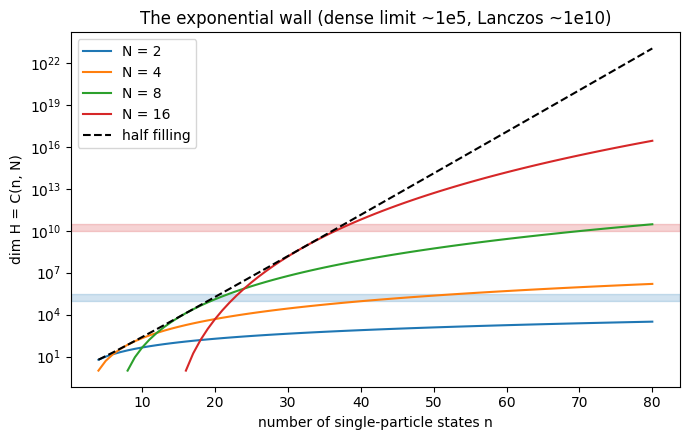

In [13]:
print(f"{'n':>5} {'C(n,n/2)':>14} {'2^n/sqrt(pi n/2)':>18}")
for nn in [10, 20, 40, 80, 160]:
    print(f"{nn:>5} {comb(nn, nn//2):>14.3e} {2.0**nn/np.sqrt(np.pi*nn/2):>18.3e}")
print("O-16 neutrons, 4 major shells: C(40,8) =", f"{comb(40,8):.3e}", "; protons and neutrons:", f"{comb(40,8)**2:.3e}")
print("largest even n with C(n,n/2) <= 1e10:", max(nn for nn in range(2, 60, 2) if comb(nn, nn//2) <= 1e10))

ns = np.arange(4, 81)
fig, ax = plt.subplots(figsize=(7, 4.5))
for N in [2, 4, 8, 16]:
    ax.semilogy(ns[ns >= N], [comb(int(m), N) for m in ns[ns >= N]], label=f"N = {N}")
ax.semilogy(ns[ns % 2 == 0], [comb(int(m), int(m)//2) for m in ns[ns % 2 == 0]], "k--", label="half filling")
ax.axhspan(1e5, 3e5, color="tab:blue", alpha=0.2); ax.axhspan(1e10, 3e10, color="tab:red", alpha=0.2)
ax.set_xlabel("number of single-particle states n"); ax.set_ylabel("dim H = C(n, N)")
ax.legend(); ax.set_title("The exponential wall (dense limit ~1e5, Lanczos ~1e10)")
plt.tight_layout(); plt.show()